# Week 1: Probability and Statistics

This notebook covers the foundational probability and statistics concepts we'll rely on throughout this course. The goal isn't to turn you into a statistician — it's to give you the vocabulary and intuition you need to understand what machine learning models are actually doing under the hood.

We'll keep the math light and the examples concrete. By the end, you should be comfortable with terms like "distribution," "expected value," and "variance" — and more importantly, you should have a picture in your head of what each one means.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

# Fix the random seed so results are reproducible
rng = np.random.default_rng(42)

# Nice plot defaults
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

---
## 1. What is a Random Variable?

A **random variable** is a quantity whose value we haven't observed yet, but whose possible outcomes we can describe.

For example, when you roll a six sided die, you don't know what number will come up, but you know there are six possibilities and each is equally likely. That's a random variable.

Random variables come in two flavors:

**Discrete**: the possible outcomes are countable. You can list them. Examples: the result of a die roll (1, 2, 3, 4, 5, or 6), the number of heads in 10 coin flips, the number of customers who arrive in an hour.

**Continuous**: the outcome can be any value in some range, and there are infinitely many possibilities. Examples: a person's height, the time until the next bus arrives, the temperature outside right now.

In [2]:
# Discrete: rolling a fair 6-sided die 20 times
die_rolls = rng.integers(low=1, high=7, size=20)
print("Die rolls (discrete):", die_rolls)

Die rolls (discrete): [1 5 4 3 3 6 1 5 2 1 4 6 5 5 5 5 4 1 6 3]


In [3]:
# Continuous: sampling heights from a realistic distribution (mean ~170cm, std ~10cm)
heights = rng.normal(loc=170, scale=10, size=20)
print("\nHeights in cm (continuous):", np.round(heights, 1))


Heights in cm (continuous): [178.8 177.8 170.7 181.3 174.7 161.4 173.7 160.4 178.8 169.5 168.2 163.2
 182.2 168.5 165.7 166.5 175.3 173.7 174.1 174.3]


---
## 2. Probability Mass Function (PMF)

For a discrete random variable, the **Probability Mass Function** (PMF) tells you the probability of each possible outcome.

For a fair 6-sided die, every face has probability 1/6. The PMF is just a table (or chart) that maps each outcome to its probability.

One key property: all the probabilities in a PMF have to add up to 1. Something has to happen when you roll the die; one of those six faces will land up, with certainty.

A bar chart is the natural way to visualize a PMF: each bar represents one outcome, and its height is that outcome's probability.

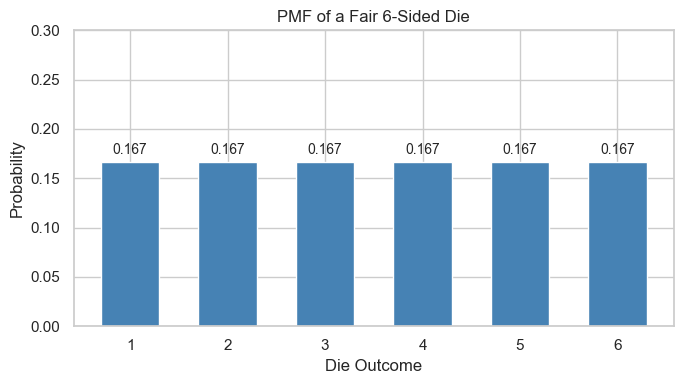

Probabilities sum to: 1.0000


In [4]:
# PMF of a fair 6-sided die
outcomes = np.array([1, 2, 3, 4, 5, 6])
probabilities = np.array([1/6] * 6)  # all equally likely

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(outcomes, probabilities, color='steelblue', edgecolor='white', width=0.6)
ax.set_xlabel('Die Outcome')
ax.set_ylabel('Probability')
ax.set_title('PMF of a Fair 6-Sided Die')
ax.set_xticks(outcomes)
ax.set_ylim(0, 0.3)

# Annotate each bar with its probability
for x, p in zip(outcomes, probabilities):
    ax.text(x, p + 0.005, f'{p:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Probabilities sum to: {probabilities.sum():.4f}")

---
## 3. Cumulative Distribution Function (CDF)

The **Cumulative Distribution Function** (CDF) answers a slightly different question than the PMF. Instead of "what's the probability of rolling exactly a 3?", it answers "what's the probability of rolling 3 or less?"

In other words, it's a running total. Start from the smallest outcome, and keep adding up probabilities as you move to larger outcomes. By the time you reach the largest possible outcome, you've added everything up and the total is 1.

For a fair die:
- P(roll ≤ 1) = 1/6
- P(roll ≤ 2) = 2/6
- P(roll ≤ 3) = 3/6
- ... and so on up to P(roll ≤ 6) = 1

The CDF always looks like a staircase — it can only stay flat or go up, never go down.

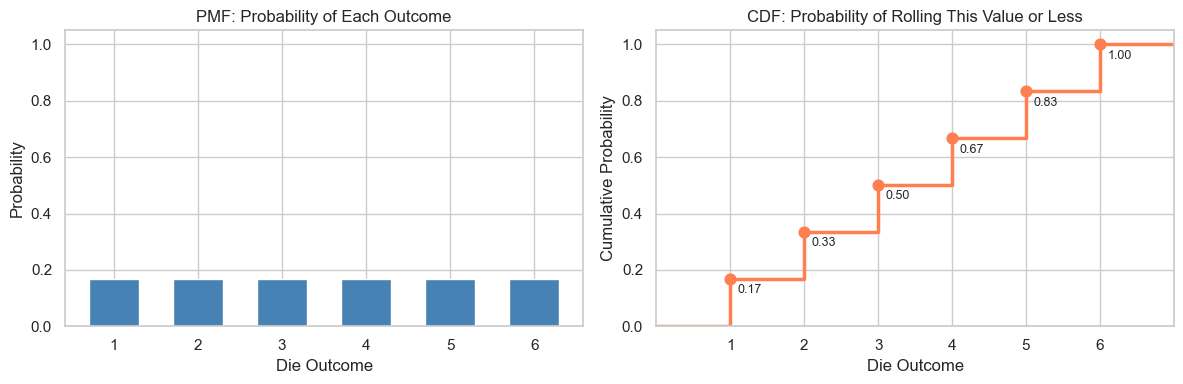

The staircase shape is the hallmark of a discrete CDF.
Each step up corresponds to one outcome in the PMF.


In [5]:
# Compute the CDF from the PMF
cdf_values = np.cumsum(probabilities)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PMF on the left
axes[0].bar(outcomes, probabilities, color='steelblue', edgecolor='white', width=0.6)
axes[0].set_xlabel('Die Outcome')
axes[0].set_ylabel('Probability')
axes[0].set_title('PMF: Probability of Each Outcome')
axes[0].set_xticks(outcomes)
axes[0].set_ylim(0, 1.05)

# CDF on the right — step chart
# We extend to show that probability is 0 before the first outcome
extended_x = np.array([0] + list(outcomes) + [7])
extended_cdf = np.array([0] + list(cdf_values) + [1])

axes[1].step(extended_x, extended_cdf, where='post', color='coral', linewidth=2.5)
axes[1].scatter(outcomes, cdf_values, color='coral', zorder=5, s=60)
axes[1].set_xlabel('Die Outcome')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('CDF: Probability of Rolling This Value or Less')
axes[1].set_xticks(outcomes)
axes[1].set_xlim(0, 7)
axes[1].set_ylim(0, 1.05)

# Annotate CDF values
for x, c in zip(outcomes, cdf_values):
    axes[1].text(x + 0.1, c - 0.05, f'{c:.2f}', fontsize=9)

plt.tight_layout()
plt.show()

print("The staircase shape is the hallmark of a discrete CDF.")
print("Each step up corresponds to one outcome in the PMF.")

---
## 4. Joint Probability

So far we've looked at one random variable at a time. But often we care about two variables at once: what's the probability that X takes on some value *and* Y takes on some value simultaneously?

This is called **joint probability**.

Let's use a coin flip example. Imagine we flip a fair coin three times.

- Let **X** = 1 if the first flip is heads, 0 if it's tails
- Let **Y** = the total number of heads across all three flips (so Y can be 0, 1, 2, or 3)

These two variables are related: if X = 1 (first flip was heads), then we already have at least one head, so Y can't be 0.

The joint distribution tells us the probability of every combination of (X, Y). A heatmap is a great way to visualize this: darker cells mean higher probability.

Joint probability table P(X=x, Y=y):
Rows = X (0=first flip tails, 1=first flip heads)
Cols = Y (total number of heads: 0, 1, 2, 3)

              Y=0    Y=1    Y=2    Y=3
X=0 (tails)         0.1250  0.2500  0.1250  0.0000
X=1 (heads)         0.0000  0.1250  0.2500  0.1250

All probabilities sum to: 1.0000


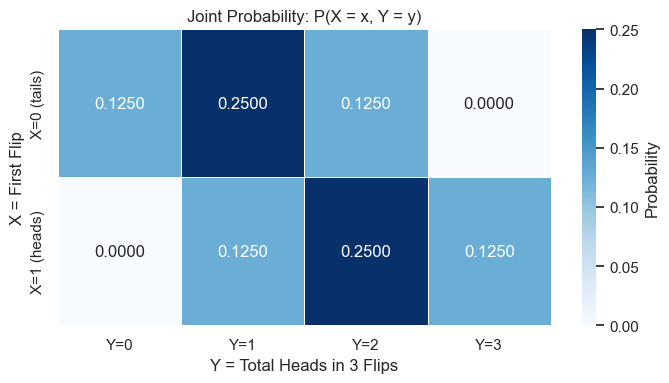


Note: P(X=1, Y=0) = 0. If the first flip was heads (X=1),
there must be at least one head total, so Y=0 is impossible.


In [6]:
# Let's compute the joint probabilities analytically.
# X = first flip (0=tails, 1=heads), Y = total heads in 3 flips.
# Each of the 8 equally-likely sequences (TTT, TTH, ..., HHH) has prob 1/8.

# Enumerate all 8 outcomes
from itertools import product

sequences = list(product([0, 1], repeat=3))  # 0=tails, 1=heads

# Build a 2x4 joint probability table: rows = X (0 or 1), cols = Y (0,1,2,3)
joint = np.zeros((2, 4))  # joint[x, y]

for seq in sequences:
    x = seq[0]          # first flip
    y = sum(seq)         # total heads
    joint[x, y] += 1/8  # each sequence has probability 1/8

print("Joint probability table P(X=x, Y=y):")
print("Rows = X (0=first flip tails, 1=first flip heads)")
print("Cols = Y (total number of heads: 0, 1, 2, 3)")
print()
print(f"{'':12}  Y=0    Y=1    Y=2    Y=3")
for x_val in [0, 1]:
    label = f"X={x_val} ({'heads' if x_val==1 else 'tails'})"
    row = '  '.join(f'{joint[x_val, y]:.4f}' for y in range(4))
    print(f"{label:18}  {row}")

print(f"\nAll probabilities sum to: {joint.sum():.4f}")

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    joint,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=['Y=0', 'Y=1', 'Y=2', 'Y=3'],
    yticklabels=['X=0 (tails)', 'X=1 (heads)'],
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Probability'}
)
ax.set_xlabel('Y = Total Heads in 3 Flips')
ax.set_ylabel('X = First Flip')
ax.set_title('Joint Probability: P(X = x, Y = y)')
plt.tight_layout()
plt.show()

print("\nNote: P(X=1, Y=0) = 0. If the first flip was heads (X=1),")
print("there must be at least one head total, so Y=0 is impossible.")

---
## 5. Expected Value (Mean)

The **expected value** (also called the mean or expectation) is the long-run average of a random variable. If you repeated an experiment over and over, thousands of times, what would the average result be?

You can think of it as the **center of gravity** of the distribution. If you printed the PMF chart on cardboard and tried to balance it on your finger, the balance point would be the expected value.

To compute it: multiply each outcome by its probability, then add everything up. In other words, it's a weighted average where the weights are the probabilities.

For a fair 6-sided die, the expected value is:

1 × (1/6) + 2 × (1/6) + 3 × (1/6) + 4 × (1/6) + 5 × (1/6) + 6 × (1/6) = **3.5**

You'll never actually roll a 3.5, but if you roll enough times, the average will get closer and closer to 3.5.

Now here's something interesting: the expected value alone doesn't fully describe a distribution. Let's look at three different dice that all have the same expected value of 3.5, but look very different.

Expected values:
  Die A (standard 1-6): E[X] = 3.5000
  Die B (2 repeated numbers): E[X] = 3.5000
  Die C (spread out): E[X] = 3.5000

Simulated averages (10,000 rolls each):
  Die A (standard 1-6): avg = 3.4753
  Die B (2 repeated numbers): avg = 3.4973
  Die C (spread out): avg = 3.5732


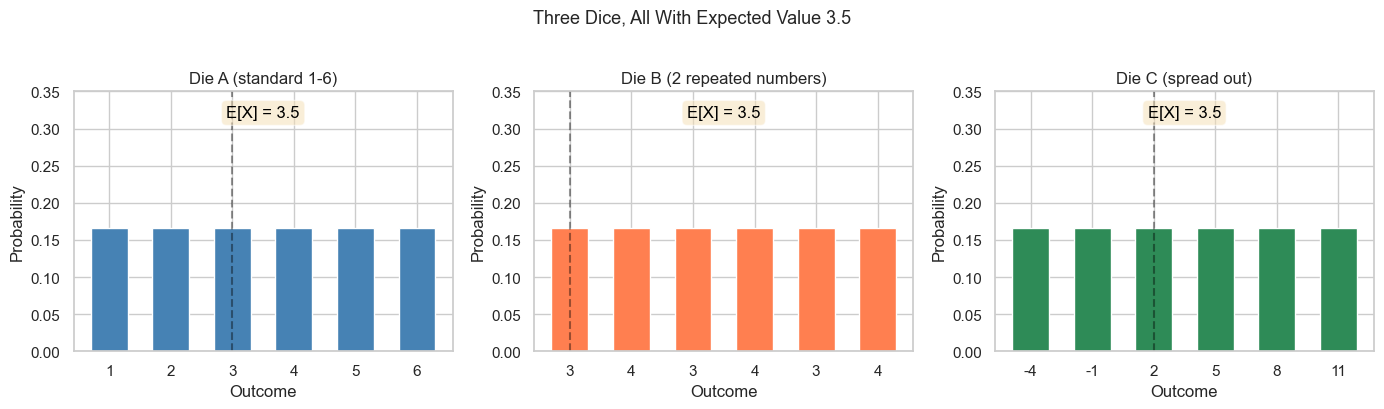


All three have E[X] = 3.5, but they look completely different.
Expected value alone doesn't capture these differences — that's where variance comes in.


In [7]:
# Three dice with the same expected value of 3.5

dice = {
    'Die A (standard 1-6)': np.array([1, 2, 3, 4, 5, 6]),
    'Die B (2 repeated numbers)': np.array([3, 4, 3, 4, 3, 4]),
    'Die C (spread out)':   np.array([-4, -1, 2, 5, 8, 11]),
}

probs = np.array([1/6] * 6)  # all fair dice

print("Expected values:")
for name, outcomes_d in dice.items():
    ev = np.sum(outcomes_d * probs)
    print(f"  {name}: E[X] = {ev:.4f}")

# Verify by simulation
print("\nSimulated averages (10,000 rolls each):")
for name, outcomes_d in dice.items():
    rolls = rng.choice(outcomes_d, size=10000)
    print(f"  {name}: avg = {rolls.mean():.4f}")

# Plot the three PMFs side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['steelblue', 'coral', 'seagreen']
for ax, (name, outcomes_d), color in zip(axes, dice.items(), colors):
    ev = np.sum(outcomes_d * probs)
    ax.bar(range(len(outcomes_d)), probs, color=color, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(outcomes_d)))
    ax.set_xticklabels(outcomes_d)
    ax.axvline(x=np.where(outcomes_d == outcomes_d[np.argmin(np.abs(outcomes_d - ev))])[0][0],
               color='black', linestyle='--', alpha=0.4, label=f'E[X]={ev:.1f}')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Probability')
    ax.set_title(name)
    ax.set_ylim(0, 0.35)
    ax.text(0.5, 0.9, f'E[X] = {ev:.1f}', transform=ax.transAxes,
            ha='center', fontsize=12, color='black',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Three Dice, All With Expected Value 3.5', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nAll three have E[X] = 3.5, but they look completely different.")
print("Expected value alone doesn't capture these differences — that's where variance comes in.")

---
## 6. Variance

**Variance** measures how spread out the values of a random variable are around its expected value. A low variance means the values cluster tightly near the mean. A high variance means they're scattered far from it.

Here's the intuition: for each possible outcome, ask "how far is this from the mean?" Then square that distance (so that outcomes below the mean and above the mean both count as being "away" from it), weight it by the outcome's probability, and add everything up.

The **standard deviation** is the square root of the variance. It's in the same units as the original data, so it's often easier to interpret.

Going back to our three dice:
- Die B (3, 4, 3, 4, 3, 4) has values that are closer together than Die A, so it should have a lower variance than Die A.
- Die C (-4, -1, 2, 5, 8, 11) has values that are farther apart from each other, so it should have *higher* variance.

Let's check.

Variance and Standard Deviation:
Die                                E[X]     Variance    Std Dev
----------------------------------------------------------------
Die A (standard 1-6)               3.50       2.9167     1.7078
Die B (2 repeated numbers)         3.50       0.2500     0.5000
Die C (spread out)                 3.50      26.2500     5.1235


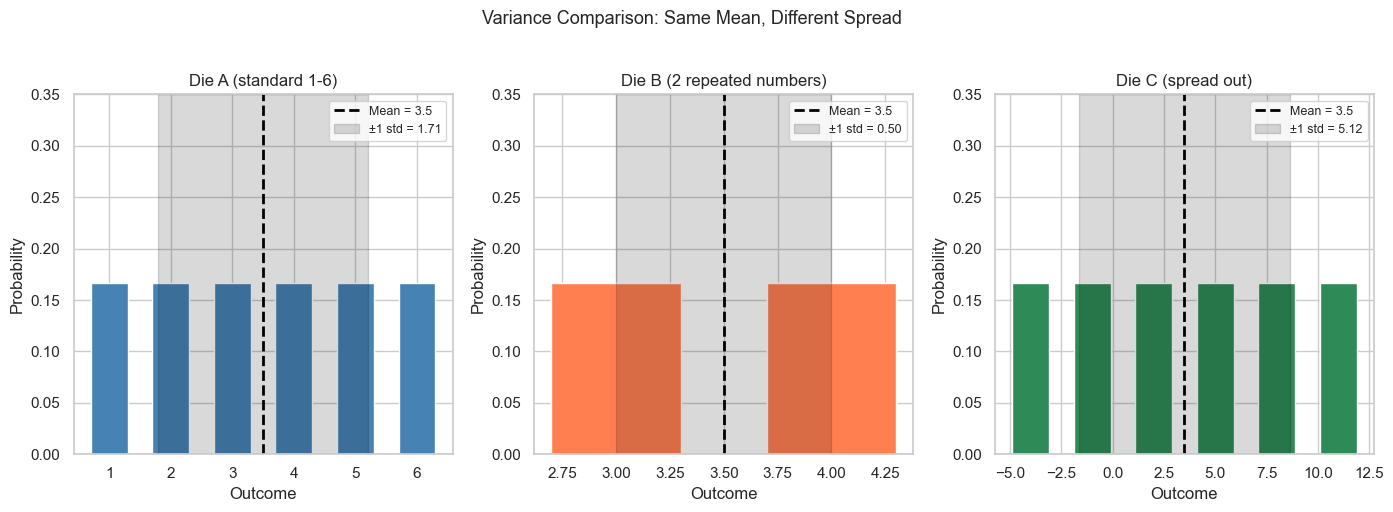


The shaded band shows ±1 standard deviation from the mean.


In [8]:
# Compute variance and standard deviation for each die
print("Variance and Standard Deviation:")
print(f"{'Die':<30} {'E[X]':>8} {'Variance':>12} {'Std Dev':>10}")
print("-" * 64)
for name, outcomes_d in dice.items():
    ev = np.sum(outcomes_d * probs)
    variance = np.sum(probs * (outcomes_d - ev)**2)
    std_dev = np.sqrt(variance)
    print(f"{name:<30} {ev:>8.2f} {variance:>12.4f} {std_dev:>10.4f}")

# Visualize with error bars showing +/- 1 std dev
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (name, outcomes_d), color in zip(axes, dice.items(), colors):
    ev = np.sum(outcomes_d * probs)
    variance = np.sum(probs * (outcomes_d - ev)**2)
    std_dev = np.sqrt(variance)

    ax.bar(outcomes_d, probs, color=color, edgecolor='white', width=0.6 * (outcomes_d[1] - outcomes_d[0]))
    ax.axvline(x=ev, color='black', linestyle='--', linewidth=2, label=f'Mean = {ev:.1f}')
    ax.axvspan(ev - std_dev, ev + std_dev, alpha=0.15, color='black', label=f'±1 std = {std_dev:.2f}')
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Probability')
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 0.35)

plt.suptitle('Variance Comparison: Same Mean, Different Spread', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nThe shaded band shows ±1 standard deviation from the mean.")

---
## 7. Covariance and Correlation

So far we've looked at the properties of individual random variables. Now let's talk about the *relationship* between two variables.

**Covariance** measures whether two variables tend to move together. If X is bigger than average when Y is bigger than average (and both are smaller than average at the same time), they have *positive* covariance. If X tends to be high when Y is low and vice versa, they have *negative* covariance. If they're unrelated, the covariance is close to zero.

The problem with covariance: its value depends on the scale of the variables. If you measure height in inches instead of centimeters, the covariance with weight changes, even though the relationship hasn't changed.

**Correlation** fixes this by normalizing covariance to always fall between -1 and 1:
- **+1** means perfectly positively related (one goes up, the other always goes up by a proportional amount)
- **-1** means perfectly negatively related
- **0** means no linear relationship

Correlation is the unit-free version of covariance — it tells you the *direction* and *strength* of the relationship, without caring about scale.

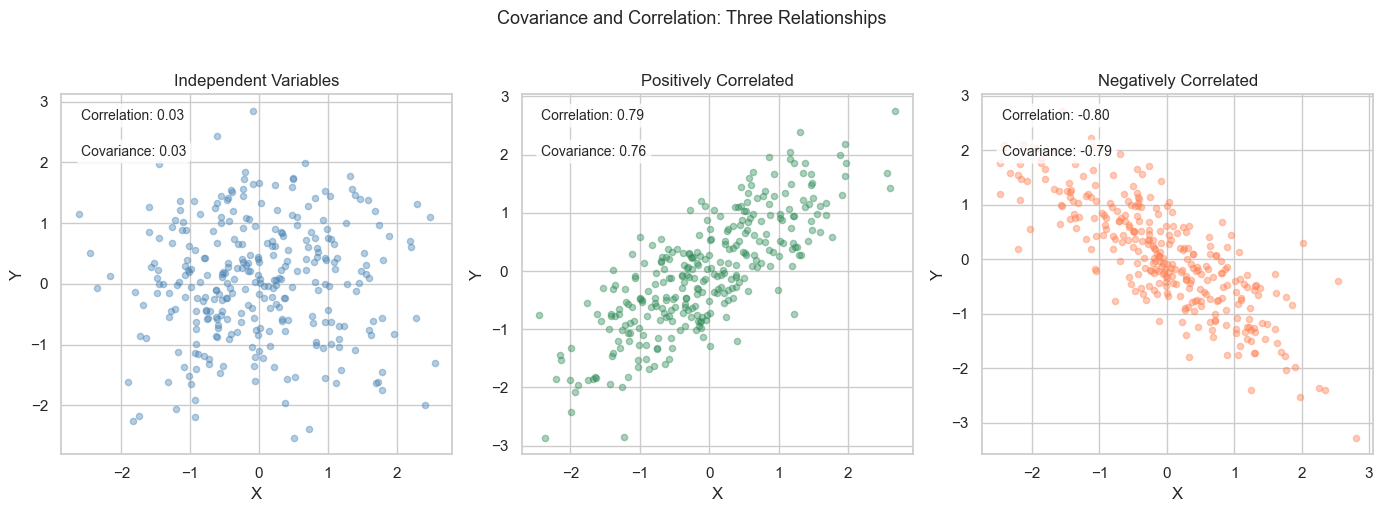

In [9]:
# Generate three pairs of variables with different relationships
n = 300

# (a) Independent variables: no relationship
x_indep = rng.normal(0, 1, n)
y_indep = rng.normal(0, 1, n)

# (b) Positively correlated: y increases with x
x_pos = rng.normal(0, 1, n)
y_pos = 0.8 * x_pos + 0.6 * rng.normal(0, 1, n)

# (c) Negatively correlated: y decreases as x increases
x_neg = rng.normal(0, 1, n)
y_neg = -0.8 * x_neg + 0.6 * rng.normal(0, 1, n)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

datasets = [
    (x_indep, y_indep, 'Independent Variables', 'steelblue'),
    (x_pos,   y_pos,   'Positively Correlated', 'seagreen'),
    (x_neg,   y_neg,   'Negatively Correlated', 'coral'),
]

for ax, (x, y, title, color) in zip(axes, datasets):
    corr = np.corrcoef(x, y)[0, 1]
    cov  = np.cov(x, y)[0, 1]
    ax.scatter(x, y, alpha=0.4, s=20, color=color)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.text(0.05, 0.93, f'Correlation: {corr:.2f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.text(0.05, 0.83, f'Covariance: {cov:.2f}', transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Covariance and Correlation: Three Relationships', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Demonstrate that correlation is scale-free but covariance is not.
# Multiply x by 100 (e.g., convert from meters to centimeters).

x_scaled = x_pos * 100  # scale up by 100x

cov_original = np.cov(x_pos, y_pos)[0, 1]
cov_scaled   = np.cov(x_scaled, y_pos)[0, 1]

corr_original = np.corrcoef(x_pos, y_pos)[0, 1]
corr_scaled   = np.corrcoef(x_scaled, y_pos)[0, 1]

print("Effect of scaling X by 100:")
print(f"  Covariance (original):  {cov_original:.4f}")
print(f"  Covariance (scaled x100): {cov_scaled:.4f}   <-- changes!")
print()
print(f"  Correlation (original): {corr_original:.4f}")
print(f"  Correlation (scaled x100): {corr_scaled:.4f}  <-- stays the same!")
print()
print("Covariance depends on the units of measurement.")
print("Correlation does not — that's why it's so useful for comparing relationships.")

Effect of scaling X by 100:
  Covariance (original):  0.7612
  Covariance (scaled x100): 76.1195   <-- changes!

  Correlation (original): 0.7903
  Correlation (scaled x100): 0.7903  <-- stays the same!

Covariance depends on the units of measurement.
Correlation does not — that's why it's so useful for comparing relationships.
